# RQ3 — Resolver Identity

> *Who resolves these conflicts — the coding agent itself or a human
> collaborator?* — PLAN.md §3 (RQ3)

Two levels of analysis per PLAN.md §5.6 / §5.7:

1. **Merge level.** Distribution of `resolver_type` over all internal
   merge commits that produced a conflict.
2. **PR level.** Distribution of `pr_outcome` ∈
   {`resolved`, `abandoned-with-conflict`, `open-with-conflict`} over
   all PRs in the universe.

Figures are saved to `analysis/figures/` as `.pdf` + `.png`.


In [1]:
# Ensure the project root is on sys.path so ``analysis.common`` imports
# cleanly whether the kernel was launched from the repo root or from
# inside analysis/.
import sys
from pathlib import Path

_here = Path.cwd()
for candidate in [_here, *_here.parents]:
    if (candidate / "analysis" / "common.py").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from analysis.common import (
    load_tables,
    build_chunk_frame, build_merge_frame, build_pr_frame,
    setup_style, save_fig,
    stratify, stratum_order,
    descriptive_table, strategy_distribution,
    STRATEGY_ORDER, STRATEGY_PALETTE,
    RESOLVER_ORDER, RESOLVER_PALETTE,
    PR_OUTCOME_ORDER, PR_OUTCOME_PALETTE,
    TOP_N_LANGUAGES,
)

setup_style()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


## 1. Load data & build analysis frames

In [2]:
tables = load_tables()
merges = build_merge_frame(tables)
prs    = build_pr_frame(tables)

failed_merges = merges[merges["has_conflict"]].copy() if not merges.empty else merges
print(f"Internal merges (total):     {len(merges):,}")
print(f"Internal merges w/ conflict: {len(failed_merges):,}")
print(f"Universe PRs:                {len(prs):,}")


Internal merges (total):     81
Internal merges w/ conflict: 11
Universe PRs:                0


## 2. Merge-level resolver distribution (global)

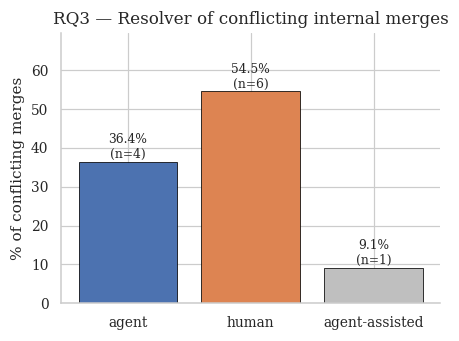

In [3]:
if not failed_merges.empty and "resolver_type" in failed_merges.columns:
    counts = failed_merges["resolver_type"].value_counts()
    counts = counts.reindex(RESOLVER_ORDER + [c for c in counts.index if c not in RESOLVER_ORDER])
    pct = counts / counts.sum() * 100

    fig, ax = plt.subplots(figsize=(4.2, 3.2))
    bars = ax.bar(
        counts.index.astype(str),
        pct.values,
        color=[RESOLVER_PALETTE.get(c, "#BFBFBF") for c in counts.index.astype(str)],
        edgecolor="black", linewidth=0.5,
    )
    for b, n, p in zip(bars, counts.values, pct.values):
        ax.text(b.get_x() + b.get_width()/2, p + 1,
                f"{p:.1f}%\n(n={n:,})", ha="center", fontsize=8)
    ax.set_ylim(0, min(100, pct.max() + 15))
    ax.set_ylabel("% of conflicting merges")
    ax.set_title("RQ3 — Resolver of conflicting internal merges")
    save_fig(fig, "rq3_resolver_global")
    plt.show()
else:
    print("No conflicting merges yet or 'resolver_type' missing.")


## 3. Figure — Merge-level resolver distribution by agent

In [4]:
if not failed_merges.empty and {"agent", "resolver_type"}.issubset(failed_merges.columns):
    agent_order = stratum_order(failed_merges, "agent")
    matrix = (
        failed_merges
        .groupby("agent")["resolver_type"]
        .value_counts()
        .unstack(fill_value=0)
        .reindex(index=agent_order, columns=RESOLVER_ORDER, fill_value=0)
    )
    pct = matrix.div(matrix.sum(axis=1).replace(0, np.nan), axis=0) * 100

    fig, ax = plt.subplots(figsize=(max(5, 0.9 * len(matrix) + 2), 3.4))
    pct.plot(
        kind="bar", stacked=True,
        color=[RESOLVER_PALETTE[c] for c in RESOLVER_ORDER],
        edgecolor="white", linewidth=0.3, ax=ax,
    )
    ax.set_ylabel("% of conflicting merges")
    ax.set_xlabel("")
    ax.set_title("RQ3 — Resolver by agent")
    ax.set_ylim(0, 100)
    ax.legend(title="Resolver", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
    save_fig(fig, "rq3_resolver_by_agent")
    plt.show()
    print("\nCounts:")
    print(matrix.to_string())


## 4. Figure — Merge-level resolver distribution by language

In [5]:
if not failed_merges.empty and {"language_top", "resolver_type"}.issubset(failed_merges.columns):
    lang_order = stratum_order(failed_merges, "language")
    matrix = (
        failed_merges
        .groupby("language_top")["resolver_type"]
        .value_counts()
        .unstack(fill_value=0)
        .reindex(index=lang_order, columns=RESOLVER_ORDER, fill_value=0)
    )
    pct = matrix.div(matrix.sum(axis=1).replace(0, np.nan), axis=0) * 100

    fig, ax = plt.subplots(figsize=(max(6, 0.7 * len(matrix) + 2), 3.4))
    pct.plot(
        kind="bar", stacked=True,
        color=[RESOLVER_PALETTE[c] for c in RESOLVER_ORDER],
        edgecolor="white", linewidth=0.3, ax=ax,
    )
    ax.set_ylabel("% of conflicting merges")
    ax.set_xlabel("Language")
    ax.set_title("RQ3 — Resolver by language (top-N)")
    ax.set_ylim(0, 100)
    ax.legend(title="Resolver", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    save_fig(fig, "rq3_resolver_by_language")
    plt.show()


## 5. PR-level outcome distribution (global)

In [6]:
if not prs.empty:
    counts = prs["pr_outcome"].value_counts().reindex(PR_OUTCOME_ORDER, fill_value=0)
    pct = counts / counts.sum() * 100

    fig, ax = plt.subplots(figsize=(5.2, 3.2))
    bars = ax.bar(
        counts.index.astype(str),
        pct.values,
        color=[PR_OUTCOME_PALETTE[c] for c in counts.index.astype(str)],
        edgecolor="black", linewidth=0.5,
    )
    for b, n, p in zip(bars, counts.values, pct.values):
        ax.text(b.get_x() + b.get_width()/2, p + 1,
                f"{p:.1f}%\n(n={n:,})", ha="center", fontsize=8)
    ax.set_ylim(0, min(100, pct.max() + 15))
    ax.set_ylabel("% of PRs")
    ax.set_title("RQ3 — PR-level outcome distribution")
    plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
    save_fig(fig, "rq3_pr_outcome_global")
    plt.show()


## 6. Figure — PR outcome by agent

In [7]:
if not prs.empty and "agent" in prs.columns:
    agent_order = stratum_order(prs, "agent")
    matrix = (
        prs.groupby("agent")["pr_outcome"]
           .value_counts()
           .unstack(fill_value=0)
           .reindex(index=agent_order, columns=PR_OUTCOME_ORDER, fill_value=0)
    )
    pct = matrix.div(matrix.sum(axis=1).replace(0, np.nan), axis=0) * 100

    fig, ax = plt.subplots(figsize=(max(5, 0.9 * len(matrix) + 2), 3.4))
    pct.plot(
        kind="bar", stacked=True,
        color=[PR_OUTCOME_PALETTE[c] for c in PR_OUTCOME_ORDER],
        edgecolor="white", linewidth=0.3, ax=ax,
    )
    ax.set_ylabel("% of PRs")
    ax.set_xlabel("")
    ax.set_title("RQ3 — PR outcome by agent")
    ax.set_ylim(0, 100)
    ax.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
    save_fig(fig, "rq3_pr_outcome_by_agent")
    plt.show()


## 7. Figure — PR outcome by language

In [8]:
if not prs.empty and "language_top" in prs.columns:
    lang_order = stratum_order(prs, "language")
    matrix = (
        prs.groupby("language_top")["pr_outcome"]
           .value_counts()
           .unstack(fill_value=0)
           .reindex(index=lang_order, columns=PR_OUTCOME_ORDER, fill_value=0)
    )
    pct = matrix.div(matrix.sum(axis=1).replace(0, np.nan), axis=0) * 100

    fig, ax = plt.subplots(figsize=(max(6, 0.7 * len(matrix) + 2), 3.4))
    pct.plot(
        kind="bar", stacked=True,
        color=[PR_OUTCOME_PALETTE[c] for c in PR_OUTCOME_ORDER],
        edgecolor="white", linewidth=0.3, ax=ax,
    )
    ax.set_ylabel("% of PRs")
    ax.set_xlabel("Language")
    ax.set_title("RQ3 — PR outcome by language (top-N)")
    ax.set_ylim(0, 100)
    ax.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    save_fig(fig, "rq3_pr_outcome_by_language")
    plt.show()


## 8. Figure — PR outcome by PR task type

In [9]:
if not prs.empty and "pr_task_type" in prs.columns:
    subset = prs.dropna(subset=["pr_task_type"]).copy()
    if subset.empty:
        print("pr_task_type only populated under --pop-only.")
    else:
        task_order = stratum_order(subset, "pr_task_type")
        matrix = (
            subset.groupby("pr_task_type")["pr_outcome"]
                  .value_counts()
                  .unstack(fill_value=0)
                  .reindex(index=task_order, columns=PR_OUTCOME_ORDER, fill_value=0)
        )
        pct = matrix.div(matrix.sum(axis=1).replace(0, np.nan), axis=0) * 100
        fig, ax = plt.subplots(figsize=(max(5, 0.8 * len(matrix) + 2), 3.4))
        pct.plot(
            kind="bar", stacked=True,
            color=[PR_OUTCOME_PALETTE[c] for c in PR_OUTCOME_ORDER],
            edgecolor="white", linewidth=0.3, ax=ax,
        )
        ax.set_ylabel("% of PRs")
        ax.set_xlabel("PR task type")
        ax.set_title("RQ3 — PR outcome by PR task type")
        ax.set_ylim(0, 100)
        ax.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
        plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
        save_fig(fig, "rq3_pr_outcome_by_task_type")
        plt.show()


## 9. Numerical tables for the paper

In [10]:
if not failed_merges.empty and "resolver_type" in failed_merges.columns:
    for axis in ("agent", "language_top", "pr_task_type"):
        if axis not in failed_merges.columns:
            continue
        table = (
            failed_merges.groupby(axis)["resolver_type"]
            .value_counts(normalize=True).mul(100)
            .unstack(fill_value=0).round(2)
        )
        table["n"] = failed_merges.groupby(axis).size()
        table = table.sort_values("n", ascending=False)
        print(f"\n=== Resolver % by {axis} (conflicting merges) ===")
        print(table.to_string())

if not prs.empty:
    for axis in ("agent", "language_top", "pr_task_type"):
        if axis not in prs.columns:
            continue
        table = (
            prs.groupby(axis)["pr_outcome"]
            .value_counts(normalize=True).mul(100)
            .unstack(fill_value=0).round(2)
        )
        table["n"] = prs.groupby(axis).size()
        table = table.sort_values("n", ascending=False)
        print(f"\n=== PR outcome % by {axis} ===")
        print(table.to_string())


---
### Outputs summary

Figures saved to `analysis/figures/`:

| File stem                         | Paper role |
|-----------------------------------|------------|
| `rq3_resolver_global`             | Headline: who resolves conflicts |
| `rq3_resolver_by_agent`           | Merge-level stratified by agent |
| `rq3_resolver_by_language`        | Merge-level stratified by language |
| `rq3_pr_outcome_global`           | PR-level outcome distribution |
| `rq3_pr_outcome_by_agent`         | PR-level by agent |
| `rq3_pr_outcome_by_language`     | PR-level by language |
| `rq3_pr_outcome_by_task_type`     | PR-level by `pr_task_type` (AIDev-pop only) |
